In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pyquasoare import approx, models

# Simplified flood routing ODE
In this notebook, we solve the non-linear routing reservoir equation. This equation approximates flood propagation along a river reach that obeys the Saint-Venant equations. These equations are complex non-linear partial differential equations that can be simplified to a conceptual reservoir. In this simplification, a river reach is represented by a reservoir which receives inflow and generates outflow that is a function of the stored volume as presented in the image below. 

![Simplified flood routing](flood_routing.png)

This dynamic can be written as the following ordinary differential equation:
$$
  \frac{dV}{dt} = Q^* - f(V)
$$
where $Q^*$ \[$L^3.T^{-1}$\] is the inflow, $V$ is the stored volume and $f$ is the outflow function. It is common to use a power function for this outflow function where
$$
f(V) = \frac{\Gamma}{\Delta} \left(\frac{V}{\Gamma}\right)^\nu
$$
where $\Gamma$ is a reservoir capacity \[$L^3$\], $\nu$ \[-\] is an exponent varying between 1 and 3 (however, higher values are also possible) and $\Delta$ is a timestep duration (say 1 hour).

Note that this ODE can be conviniently rewritten in terms of the storage level $x=V/\Gamma$:
$$
  \frac{dx}{dt} = \frac{Q^*}{\Gamma} - \frac{x^\nu}{\Delta}
$$


We intent to solve this equation which does not have a general analytical solution in the rest of this notebook.

# Approximate flux function using piecewise quadratic function
There are two flux functions in the previous ODE:
* The constant function $f_1(x) = Q^*/\Gamma$
* The function $f_2(x) = -x^\nu / \Delta$

The QuaSoARe solver first require these two functions to be approximated by piecewise-quadratic function. This is done with the [approx.quad_coefficient_matrix](https://github.com/csiro-hydroinformatics/pyquasoare/blob/e513eeaa10b3875f83d671806c0cb1783b0d36fd/src/pyquasoare/approx.py#L267) function in the pyquasoare package.

QuaSoARe allows defining flux functions up to a multiplicative constant. This is useful if we need to adjust the capacity $\Gamma$ or the timestep duration $\Delta$. Consequently, we now define the flux functions as:
* $f_1(x) = 1$
* $f_2(x) = -x^\nu$

The QuaSoARe interpolation requires the definitions of interpolation nodes $\alpha_1, \dots, \alpha_N$. Here we assume that the nodes are equidistant in the interval $[0, 1]$.  

In [3]:
# Define the interpolation nodes
nalphas = 3
alphas = np.linspace(0, 1, nalphas)

# Define the exponent alpha
nu = 3

def f1(x):
    return np.ones_like(x)

def f2(x):
    return -x**nu

coefs = approx.quad_coefficient_matrix([f1, f2], alphas)

The result of the interpolation can be checked with the [approx.quad_fun_from_matrix](https://github.com/csiro-hydroinformatics/pyquasoare/blob/e513eeaa10b3875f83d671806c0cb1783b0d36fd/src/pyquasoare/approx.py#L326) function.

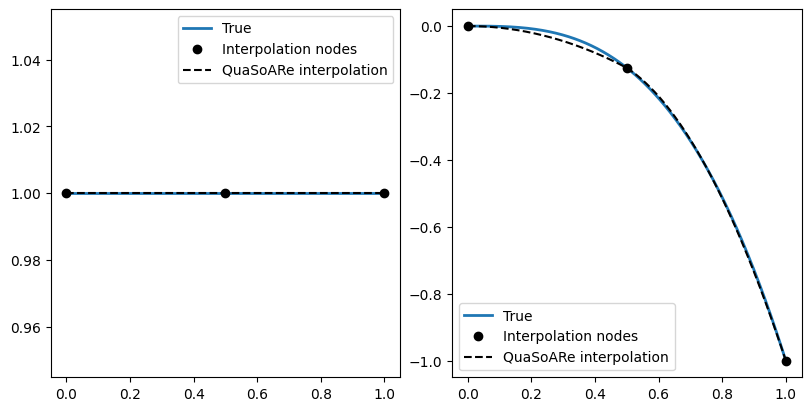

In [4]:
xx = np.linspace(0, 1, 500)
fint = approx.quad_fun_from_matrix(alphas, coefs, xx)

fig, axs = plt.subplots(ncols=2, figsize=(8, 4), layout="constrained")
for ifx in range(2):
    ax = axs[ifx]
    fx = [f1, f2][ifx]
    ax.plot(xx, fx(xx), label="True", lw=2)
    ax.plot(alphas, fx(alphas), "ko", label="Interpolation nodes")
    ax.plot(xx, fint[:, ifx], "k--", label="QuaSoARe interpolation")
    ax.legend()

# Run the solver with given inputs
Once the interpolation of the flux function is completed, we can run the QuaSoARe solver with a series of inputs. 
As indicated above, the flux functions were defined up to a multiplicative constant. These constant can be defined for each timestep and are named "scalings".

Running the QuaSoARe solver using timeseries inputs is done via the ["models.quad_model"](https://github.com/csiro-hydroinformatics/pyquasoare/blob/e513eeaa10b3875f83d671806c0cb1783b0d36fd/src/pyquasoare/models.py#L14) function. 

Note that the solver computes the integrated fluxes associated with each flux function over a particular timestep as follows:
$$
    F_i = \int_0^\Delta f_i(x) dt
$$
In the case presented above, this flux needs to be rescaled by $\Gamma/\Delta$ to obtain the reach outflow:
$$
    Q_i = \frac{\Gamma}{\Delta} F_i
$$


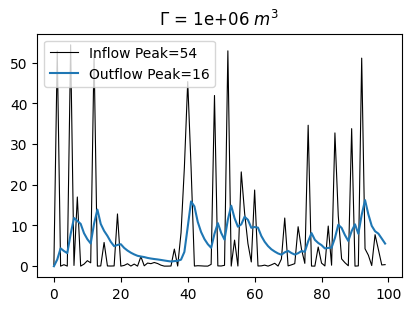

In [9]:
# Timestep (one hour = 3600 sec)
Delta = 3600

# Random inflow timeseries
nval = 100
Qstars = np.exp(np.random.uniform(-4, 4, size=nval))

# We run the solver for a given reservoir capacities
Gamma = 1e6
x0 = 0.
nval = 100

# Define flux scalings
scalings = np.ones((nval, 2))
scalings[:, 0] = Qstars / Gamma
scalings[:, 1] = 1 / Delta
    
# Solve
_, x, fluxes = models.quad_model(alphas, scalings, coefs, x0, Delta)

# plot
fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
time = np.arange(nval)

ax.plot(time, Qstars, "k-", lw=0.8, label=f"Inflow Peak={Qstars.max():0.0f}")
qout = -fluxes[:, 1] * Gamma / Delta
ax.plot(time, qout, label=f"Outflow Peak={qout.max():0.0f}")
ax.set(title=f"$\\Gamma$ = {Gamma:0.0e} $m^3$")
ax.legend(loc=2)

# Testing different parameters
We can easily compare the solution obtained with different values for parameters $\Gamma$ (capacity) and $\nu$ (power exponent).

In [7]:
# define a parameterised solution function
def solve(x0, Gamma, nu):
    # 1. approximate flux functions
    coefs = approx.quad_coefficient_matrix([f1, f2], alphas)

    # 2. define flux scalings
    scalings = np.ones((nval, 2))
    scalings[:, 0] = Qstars / Gamma
    scalings[:, 1] = 1 / Delta
    
    # Solve
    _, x, fluxes = models.quad_model(alphas, scalings, coefs, x0, Delta)
    return -fluxes[:, 1] * Gamma / Delta

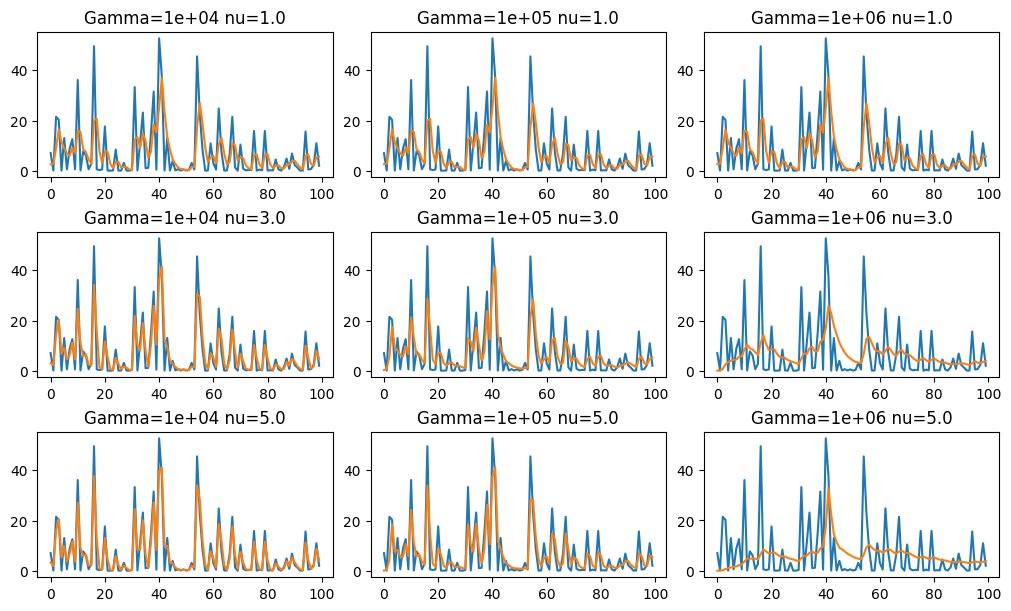

In [8]:
Gammas = [1e4, 1e5, 1e6]
nus = [1., 3., 5.]
mosaic = [[f"{g}/{n}" for g in Gammas] for n in nus]
fig = plt.figure(figsize=(10, 6), layout="constrained")
axs = fig.subplot_mosaic(mosaic)
x0 = 0.
for aname, ax in axs.items():
    Gamma, nu = [float(v) for v in aname.split("/")]
    qout = solve(x0, Gamma, nu)
    ax.plot(time, Qstars)
    ax.plot(time, qout)
    ax.set(title=f"Gamma={Gamma:0.0e} nu={nu:0.1f}")

The solution for increasing reservoir capacity demonstrates how flood routing progressively attenuates the flood peak for larger stored volumes.